In [1]:
# Step 1: Import Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
import tensorflow as tf


In [2]:
# Step 2: Paths and Parameters
train_dir = 'dataset/train'
val_dir = 'dataset/val'
img_height, img_width = 224, 224
batch_size = 32
epochs = 10


In [3]:
# Step 3: Data Preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)

# Save class indices
with open('class_indices.json', 'w') as f:
    json.dump(train_generator.class_indices, f)


Found 4656 images belonging to 10 classes.
Found 686 images belonging to 10 classes.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-59.96991..74.12279].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-60.54975..65.470795].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..48.120182].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-60.63773..38.215084].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-52.566757..27.621624].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-57.405586..69.31604].


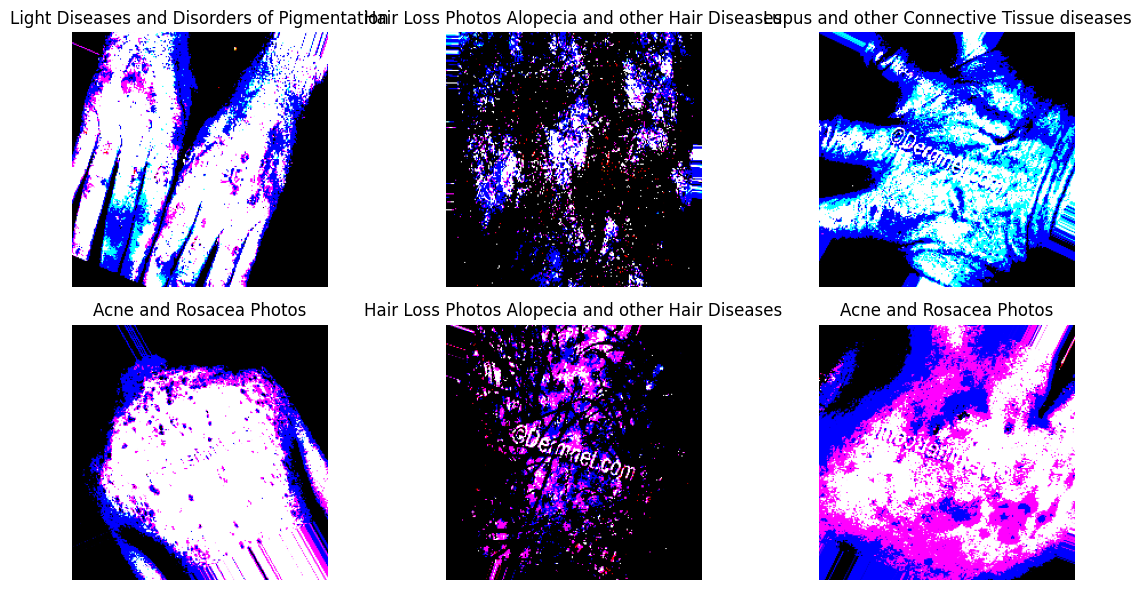

In [4]:
# Step 4: Visualize Sample Images
class_names = list(train_generator.class_indices.keys())
images, labels = next(train_generator)

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow((images[i] + 1) / 2)  # de-normalize visualization
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [5]:
# Step 5: Build ResNet101 Model
base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

In [6]:
# Step 6: Train the Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    verbose=1
)


Epoch 1/50
146/146 [==============================] - 896s 6s/step - loss: 3.0536 - accuracy: 0.1742 - val_loss: 2.2972 - val_accuracy: 0.2536
Epoch 2/50
146/146 [==============================] - 845s 6s/step - loss: 2.4932 - accuracy: 0.2695 - val_loss: 1.9136 - val_accuracy: 0.3353
Epoch 3/50
146/146 [==============================] - 763s 5s/step - loss: 2.2696 - accuracy: 0.3267 - val_loss: 1.7620 - val_accuracy: 0.4111
Epoch 4/50
146/146 [==============================] - 742s 5s/step - loss: 2.0853 - accuracy: 0.3640 - val_loss: 1.6253 - val_accuracy: 0.4606
Epoch 5/50
146/146 [==============================] - 746s 5s/step - loss: 1.9481 - accuracy: 0.3902 - val_loss: 1.5666 - val_accuracy: 0.4752
Epoch 6/50
146/146 [==============================] - 745s 5s/step - loss: 1.8654 - accuracy: 0.4225 - val_loss: 1.4898 - val_accuracy: 0.4869
Epoch 7/50
146/146 [==============================] - 743s 5s/step - loss: 1.7847 - accuracy: 0.4506 - val_loss: 1.4785 - val_accuracy: 0.5044

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    verbose=1
)

Epoch 1/50
  2/146 [..............................] - ETA: 10:37 - loss: 0.9209 - accuracy: 0.7031

In [8]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    verbose=1
)

Epoch 1/100
73/73 [==============================] - 367s 5s/step - loss: 0.8710 - accuracy: 0.7122 - val_loss: 0.8170 - val_accuracy: 0.7172
Epoch 2/100
73/73 [==============================] - 392s 5s/step - loss: 0.8626 - accuracy: 0.7019 - val_loss: 0.8319 - val_accuracy: 0.7114
Epoch 3/100
73/73 [==============================] - 408s 6s/step - loss: 0.8679 - accuracy: 0.7040 - val_loss: 0.8028 - val_accuracy: 0.7201
Epoch 4/100
73/73 [==============================] - 484s 7s/step - loss: 0.8728 - accuracy: 0.6972 - val_loss: 0.8151 - val_accuracy: 0.7172
Epoch 5/100
73/73 [==============================] - 484s 7s/step - loss: 0.8815 - accuracy: 0.7070 - val_loss: 0.8152 - val_accuracy: 0.7114
Epoch 6/100
73/73 [==============================] - 446s 6s/step - loss: 0.8689 - accuracy: 0.6980 - val_loss: 0.7972 - val_accuracy: 0.7230
Epoch 7/100
73/73 [==============================] - 417s 6s/step - loss: 0.8815 - accuracy: 0.7015 - val_loss: 0.7924 - val_accuracy: 0.7318
Epoch 

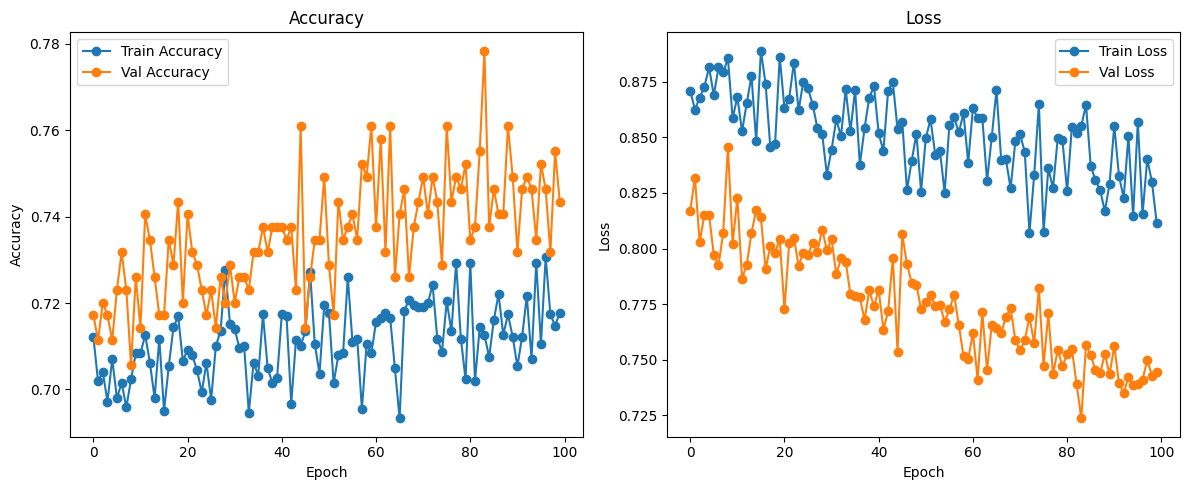

In [9]:
# Step 7: Accuracy & Loss Graphs
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [10]:
# Step 8: Classification Report
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

11/11 [==============================] - 59s 5s/step
Classification Report:

                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.55      0.69      0.61        35
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.83      0.94      0.88        31
                                          Atopic Dermatitis Photos       0.77      0.77      0.77        31
                                            Bullous Disease Photos       1.00      0.76      0.87        55
                Cellulitis Impetigo and other Bacterial Infections       1.00      0.41      0.58        34
                                                     Eczema Photos       0.67      0.67      0.67        33
                                      Exanthems and Drug Eruptions       0.71      0.67      0.69        30
                 Hair Loss Photos Alopecia and other Hair 

In [9]:
# Step 9: Save Model
model.save('vitamindeficiency.h5')
print("Model saved as vitamindeficiency.h5")


Model saved as vitamindeficiency.h5
